# librerias

In [1]:
import time
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier,VotingClassifier

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
class HybridGradientBoosting(BaseEstimator, ClassifierMixin):
    def __init__(self, 
                 learning_rate=0.05, 
                 max_depth=3, 
                 min_child_weight=5,
                 n_estimators=200, 
                random_state=0):

        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_child_weight = min_child_weight
        self.n_estimators = n_estimators
        self.random_state = random_state

        # Modelo base
        self.base_logit = LogisticRegression(
            multi_class="ovr", solver='saga',
            penalty='elasticnet', l1_ratio=0.5
        )

        # Declaración (importante para sklearn)
        self.params = None
        self.booster = None

    def fit(self, X, y):

        # 1️⃣ Modelo base
        self.base_logit.fit(X, y)
        logits = self.base_logit.decision_function(X)

        # 2️⃣ Construimos parámetros antes de usarlos
        num_class = len(np.unique(y))
        self.params = {
            "objective": "multi:softprob",
            "num_class": num_class,
            "learning_rate": self.learning_rate,
            "max_depth": self.max_depth,
            "min_child_weight": self.min_child_weight,
            "subsample": 0.7,
            "colsample_bytree": 0.7,
            "eval_metric": "mlogloss",
            "random_state": self.random_state,
        }

        # 3️⃣ Booster usando base_margin
        dtrain = xgb.DMatrix(X, label=y, base_margin=logits)

        self.booster = xgb.train(
            self.params,
            dtrain,
            num_boost_round=self.n_estimators,
            verbose_eval=False
        )

        return self

    def predict_proba(self, X):
        logits = self.base_logit.decision_function(X)
        dtest = xgb.DMatrix(X)
        dtest.set_base_margin(logits)
        preds = self.booster.predict(dtest)
        return preds

    def predict(self, X):
        preds = self.predict_proba(X)
        return np.argmax(preds, axis=1)

# Carga de datos

In [4]:
X_train = pd.read_csv('data/X_train.csv')
y_train = pd.read_csv('data/y_train.csv')
X_test = pd.read_csv('data/X_test.csv')
y_test = pd.read_csv('data/y_test.csv')

In [5]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((170152, 15), (42539, 15), (170152, 1), (42539, 1))

In [6]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [7]:
mapping = {"Low": 0, "Medium": 1, "High": 2}
y_train_enc = y_train.map(mapping)
y_test_enc = y_test.map(mapping)
labels = list(mapping.values())              
target_names = list(mapping.keys())  

In [8]:
from funciones import *

# Modelo implementado

In [9]:
modelo_hgb = HybridGradientBoosting(
    learning_rate=0.05, max_depth=3, min_child_weight=5,n_estimators=200
)

pipeline_hgb = crear_pipeline(modelo=modelo_hgb, tipo="balanceo_smote")

In [10]:
start = time.time()
modelo_original=pipeline_hgb.fit(X_train, y_train_enc)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.41 minutos


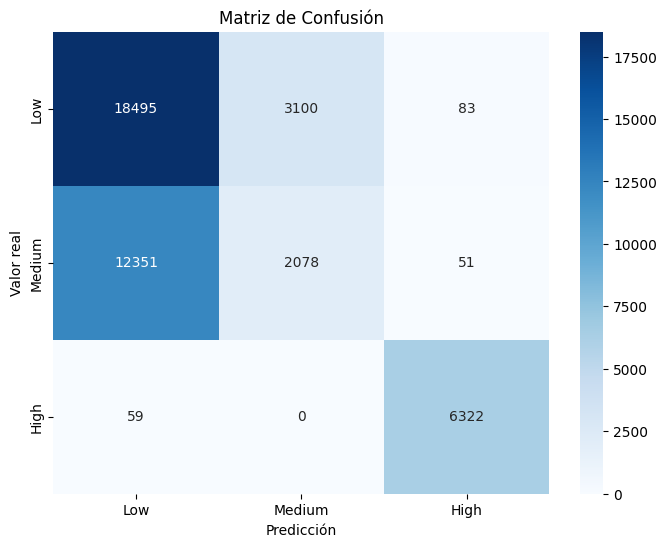


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.85      0.70     21678
      Medium       0.40      0.14      0.21     14480
        High       0.98      0.99      0.98      6381

    accuracy                           0.63     42539
   macro avg       0.66      0.66      0.63     42539
weighted avg       0.59      0.63      0.58     42539



{'Accuracy': 0.6322433531582783,
 'Precision (macro)': 0.6596680718736361,
 'Recall (macro)': 0.6624770663930821,
 'F1-score (macro)': 0.6332799424752369,
 'ROC-AUC': 0.7575713213408571}

In [11]:
evaluar_modelo(modelo_original,X_test,y_test_enc,class_map=mapping)

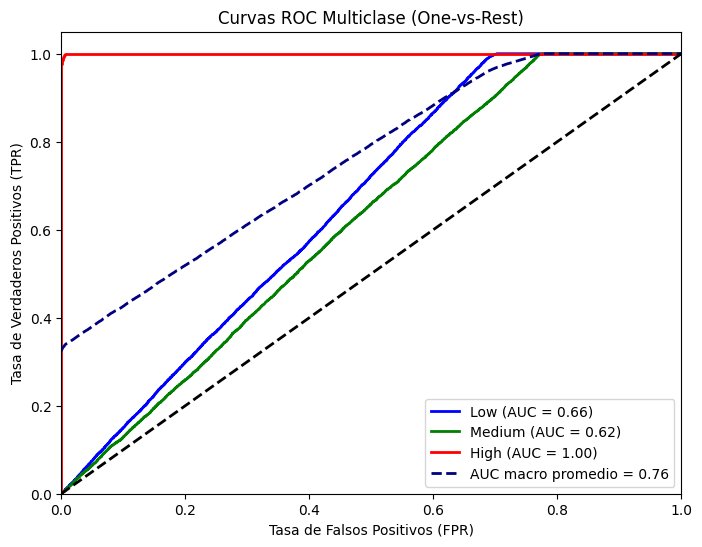

In [12]:
plot_roc_multiclass2(modelo_original,X_test,y_test_enc,class_map=mapping)

# Gridsearch de Hybrid Boosting

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

In [14]:
scoring = {
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro',
    'roc_auc_ovr': 'roc_auc_ovr'
}

In [15]:
param_grid = {
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__n_estimators": [100, 150, 200],
     "model__min_child_weight": [1, 3, 5]
}

In [16]:
pipeline = crear_pipeline(
    modelo=HybridGradientBoosting(),
    tipo="balanceo_smote"
)

In [17]:
start = time.time()
grid_hybrid = gridsearch_pipeline(pipeline, param_grid, X_train, y_train_enc,cv=cv, scoring=scoring)
end = time.time()

In [18]:
print("Hybrid Gradient Boosting - Mejor score: ", grid_hybrid.best_score_)
print("Hybrid Gradient Boosting - Mejores parametros :", grid_hybrid.best_params_)
print(f"Tiempo: {(end - start)/60:.2f} minutos\n")

Hybrid Gradient Boosting - Mejor score:  0.6676396083991578
Hybrid Gradient Boosting - Mejores parametros : {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__n_estimators': 100}
Tiempo: 173.03 minutos



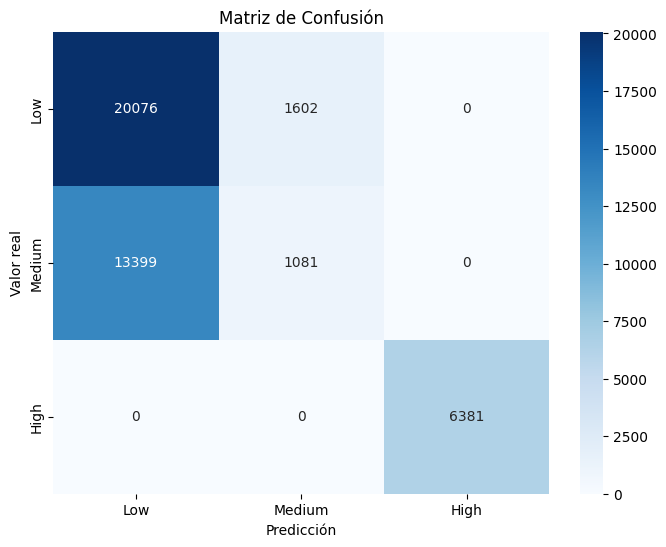


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.93      0.73     21678
      Medium       0.40      0.07      0.13     14480
        High       1.00      1.00      1.00      6381

    accuracy                           0.65     42539
   macro avg       0.67      0.67      0.62     42539
weighted avg       0.59      0.65      0.56     42539



{'Accuracy': 0.6473588941912127,
 'Precision (macro)': 0.667546112027981,
 'Recall (macro)': 0.6669182966258024,
 'F1-score (macro)': 0.6179932741429576,
 'ROC-AUC': 0.756836862114389}

In [19]:
evaluar_modelo(grid_hybrid.best_estimator_,X_test,y_test_enc,class_map=mapping)